In [16]:
import collections
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
from attr import dataclass

from hispec_laser_helpers import *
MM_SM_SWITCH_THROUGHPUT = .8

reflection = {'J': (1270, 1430),
              'JH': (1430,),
              'H': (1430, 1510),
              'J+H': (1270,1430,1510)}

launch_throughput = {#980: (.99, .75),
                     #1410: (.97, .75),
                     #1550: (.97, .75),
                     1028: (.99, .75),
                     1270: (.99, .75),
                     1430: (.97, .75),
                     1510: (.97, .75),
                     2330: (.97, .75),
                    }

couplings = {'normal':.75, 'piaa':.9, 'vortex': .3, 'vortex_dark':3.2e-4, 'mm':.99, 'unity':1}

receive_throughput = {'rspec': (.3,),  #transmission terms
                      'bspec': (.41,),
                      'bfemto': (.98, MM_SM_SWITCH_THROUGHPUT),
                      'bfemto_mm': (.98,),
                      'rfemto': (.98, MM_SM_SWITCH_THROUGHPUT),
                      'rfemto_mm': (.98,),
                      'atc': (.99,),
                     }

fei_throughputs = {'forward_atc':{'J':{1040: .02, 1270:.8, 1430:.8, 1510: .02, 2330: .02},
                                  'JH':{1040: .02, 1270:.02, 1430:.8, 1510: .02, 2330: .02},
                                  'H':{1040: .02, 1270:.02, 1430:.8, 1510: .8, 2330: .02},
                                  'J+H':{1040: .02, 1270:.8, 1430:.8, 1510: .8, 2330: .02}
                                  },
                   'backward_atc':{'J': {1430:.008/4},
                                  'JH': {1430:.002/4},
                                  'H': {1430:.002/4},
                                  'J+H': {1430:.005/4}},
                   'forward_rfocus':{'J':{1040: None, 1270: None, 1430:None, 1510:0.12, 2330:0.12},
                                    'JH':{1040: None, 1270: None, 1430:None, 1510:.12, 2330:.12},
                                    'H':{1040: None, 1270: None, 1430:None, 1510: 3e-4, 2330: .12},
                                    'J+H':{1040: None, 1270: None, 1430:None, 1510: 2e-3, 2330: .12},
                                    },
                   'forward_bfocus':{'H':{1040:0.17, 1270:0.17, 1430:None, 1510:None, 2330:None},
                                    'JH':{1040:0.17, 1270:0.17, 1430:None, 1510:None, 2330:None},
                                    'J':{1040:0.17, 1270:4e-3, 1430:None, 1510:None, 2330:None},
                                    'J+H':{1040:0.17, 1270:1e-3, 1430:None, 1510:None, 2330:None},
                                     },
                   }

thor_qe = {1430:.5/1.2, 1510:.2/1.2, 2330:1.0}
femto_qe = {1040:.68, 1270:.85, 1430:.93}

rspec = Spec('rspec', '/Users/jibailey/src/coo_playground/data/hispec_orders/orders_20220608C_HISPEC_SPECTRO_HK_pyechelle.csv',
             '/Users/jibailey/src/coo_playground/data/hispec_orders/RSPEC_Spectral_Resolution_v2.txt')
bspec = Spec('bspec', '/Users/jibailey/src/coo_playground/data/hispec_orders/orders_20220608C_HISPEC_SPECTRO_YJ_pyechelle.csv',
             '/Users/jibailey/src/coo_playground/data/hispec_orders/BSPEC_Spectral_Resolution_v2.txt')

# 1.2+4+1.5 A TEC @1V
# .25+.07*4+.12 A LD @ 1.65 V
# total draw 7.8W ~1.56A@5V
# 1040LD-1-0-0-2-FBG
# forward_y_diode = Diode(1040 * u.nm, width=0.1*u.nm, threshold_current=60*u.mA, max_current=250*u.mA,
#                         dlambda_dA=0*u.nm/u.mA, voltage=1.65*u.V, dlambda_dT=5e-3*u.nm/u.K,
#                         dP_dI=.523*u.mW/u.mA, tec_current=1.5*u.A)  # to spec or PD

#FLPD-1028-70-DFB-BTF
forward_y_diode = Diode(1028 * u.nm, width=2*u.MHz, threshold_current=47*u.mA, max_current=250*u.mA,
                        dlambda_dA=0.015*u.nm/u.mA, voltage=1.3*u.V, dlambda_dT=0.12*u.nm/u.K,
                        dP_dI=.18*u.mW/u.mA, tec_current=1.2*u.A)  # to spec or PD

#1270LD-1-0-0-1
forward_j_diode = Diode(1270 * u.nm, width=2*u.MHz, threshold_current=8*u.mA, max_current=70*u.mA,
                        dlambda_dA=0.003*u.nm/u.mA, voltage=1.7*u.V, dlambda_dT=0.08*u.nm/u.K,
                        dP_dI=.166*u.mW/u.mA, tec_current=1*u.A)  # to spec or PD

#1430LD-1-0-0-1
atc_diode = Diode(1430 * u.nm, width=2*u.MHz, threshold_current=8*u.mA, max_current=70*u.mA,
                  dlambda_dA=0.003*u.nm/u.mA, voltage=1.7*u.V, dlambda_dT=0.08*u.nm/u.K,
                  dP_dI=.166*u.mW/u.mA, tec_current=1*u.A)   # to atc

#1510LD-1-0-0 -1
forward_h_diode = Diode(1510 * u.nm, width=0.5*u.MHz, threshold_current=8*u.mA, max_current=70*u.mA,
                        dlambda_dA=0.003*u.nm/u.mA, voltage=1.7*u.V, dlambda_dT=0.08*u.nm/u.K,
                        dP_dI=.166*u.mW/u.mA, tec_current=1*u.A)  # to spec or PD

# FLPD-2330-03-DFB-BTF
forward_k_diode = Diode(2330 * u.nm, width=2*u.MHz, threshold_current=25*u.mA,
                        dlambda_dA=0.015*u.nm/u.mA, voltage=1.65*u.V, dlambda_dT=0.12*u.nm/u.K,
                        dP_dI=.031*u.mW/u.mA, max_current=120*u.mA, tec_current=1.2*u.A)  # to spec or PD


atc = ATC()

rfemto = Femto('rfemto', noise=2.11 * u.picowatt / u.Hz ** 0.5, saturation=1.62 * u.microwatt, qe=thor_qe)
bfemto = Femto('bfemto', noise=7.5 * u.femtowatt / u.Hz ** 0.5, saturation=110 * u.picowatt, qe=femto_qe)

# Femto 1.47e4 levels
# Thorlabs 7.68e5 levels

configs = set(x for v in fei_throughputs.values() for x in v.keys())

backward_diodes = {'b': [atc_diode], 'r': [atc_diode]}
forward_diodes = {'b': [forward_y_diode, forward_j_diode, atc_diode],
                  'r': [forward_h_diode, forward_k_diode, atc_diode]}

In [2]:
def doplot(fei_routes, coupling_key, detectors, attens, texp, fei_throughputs, exclude_reflected_diode=True, collapse_func=np.sum):
    data = {}
    for route in fei_routes:
        dir = route.split('_')[0]
        det = detectors[route]
        coupling = coupling_key[route]
        print(route, det.name, coupling)
        for dichroic in fei_throughputs[route]:
            for d in diodes:

                wave = int(d.wavelength.value)

                atten = attens[wave]
                if isinstance(atten, dict):
                    try:
                        atten = atten[dichroic]
                    except KeyError:
                        pass

                if isinstance(atten, dict):
                    try:
                        atten = atten[dir]
                    except KeyError:
                        raise 'attens are keyed on dichroic or direction'

                if exclude_reflected_diode and det.name!= 'atc' and wave in reflection[dichroic]:
                    print(f'Skipping reflected diode for {route}:{dichroic}:{wave} nm.')
                    continue

                if fei_throughputs[route][dichroic][wave] is None:
                    print(f'No FEI transmission for {route}:{dichroic}:{wave} nm.')
                    continue

                tput = (atten*
                        np.prod(launch_throughput[wave])*
                        fei_throughputs[route][dichroic][wave]*
                        np.prod(receive_throughput[det.name])*
                        couplings.get(coupling, coupling))

                flux = d.flux(spectrum=isinstance(det, Spec), tput=tput)
                et=texp[f'{dir}_{det.name}']
                print(f'ET for {det.name} in {dir} is {et}')
                detection = det.detect(d.wavelength, flux, texp=et, width=d.width)

                lstyle='--' if 'atc' in det.name else '-'
                label = f'{route} {wave} nm {dichroic} {det.name}'
                if isinstance(detection, dict):
                    for k, val in detection.items():
                        plt.plot(d.currents, val.sn(saturated=0, collapse=collapse_func), label=f'{label}:{k}', alpha=1, linestyle=lstyle)
                else:
                    plt.plot(d.currents, detection.sn(saturated=0, collapse=collapse_func), label=label, alpha=1, linestyle=lstyle)
                data[(route, dichroic, wave)] = (d, detection)
    plt.xlabel('LD Current (mA)')
    plt.ylabel('Net S/N' if collapse_func==np.sum else f'{collapse_func}(S/N)')
    plt.legend(loc='upper right')
    return data


In [ ]:
@dataclass
class Sensor:
    detector: Femto
    rate: float

@dataclass
class PathElement:
    name: str
    data: any

@dataclass
class Transmitted:
    fluxes: dict[str, float]

    def __add__(self, other):
        return {k: self.fluxes.get(k,0)+other.fluxes.get(k,0) for k in set(self.fluxes) | set(other.fluxes)}

class Node:
    name: str
    item: Diode|Sensor|PathElement
    parents: list['Node'] = None
    children: list['Node'] = None
    item: Any = None
    def __init__(self, name, parents=None, children=None):
        self.name = name
        if parents is not None:
            self.parents = parents
        if children is not None:
            self.children = children

    def __repr__(self):
        return f'{self.name}'

    def output(self):
        input = (sum([p.output() for p in self.parents])
        if isinstance(self.item, Diode)
        + [self.item])



@dataclass
class TIBConfig:
    name: str  = ''
    detector: Femto|None = None
    diode: Diode|None = None
    voa: float|None = None
    forward_launch_chain : list[tuple[str, float]] = None
    retro_launch_chain : list[tuple[str, float]] = None
    retro_receive_chain : list[tuple[str, float]] = None
    forward_receive_chain : list[tuple[str, float]] = None
    forward_atc_rate : float|None = None
    retro_atc_rate : float|None = None
    spec_rate : float = None
    diode_rate : float = None

"""

"""
from collections import defaultdict
OFS_LAUNCH_COUPLING = defaultdict(lambda: .75)
FOCUS_COUPLING = {'normal':.75,
                  'piaa':.9,
                  'vortex': .3,
                  'vortex_dark':3.2e-4,
                  'mm':.99,
                  'unity':1}
OFS_MODE_COUPLING = {1028: 1 - .2797, 1270: 1 - .1212, 1430: 1 - .869}
ZBLAN_MODE_COUPLING = {1510: 1 - .6933, 2330: 1 - .5318, 1430: 1 - .6338}
SPLITTER = {1430:.23}

STATIC_ATTENUATORS = {
    1028: {3: 1.72, 5: 3.42, 10: 5.58, 20: 12.67, 25: 19.14},
    1270: {3: 3.15, 5: 5.20, 10: 9.99, 20: 20.34, 25: 29.39},
    1430: {3: 2.96, 5: 5.22, 10: 9.52, 20: 20.49, 25: 27.67},
    1510: {3: 3.04, 5: 3.96, 10: 9.63, 20: 22.86, 25: 26.91},
    2330: {3: 2.83, 5: 3.06, 10: 7.92, 20: 10.12, 25: 12.16},
}

WDM_YJ = {1028: 0.309737483, 1270: 0.213445037, 1430: 0.228249063}
WDM_HK = {1430: 0.5, 1510: 0.5, 2330: 0.5}


MM_SM_SWITCH_THROUGHPUT = .8

reflection = {'J': (1270, 1430),
              'JH': (1430,),
              'H': (1430, 1510),
              'J+H': (1270,1430,1510)}

launch_throughput = {
                     1028: (.99, .75),
                     1270: (.99, .75),
                     1430: (.97, .75),
                     1510: (.97, .75),
                     2330: (.97, .75),
                    }

FORWARD_CHAIN_ATC = [STATIC_ATTENS, VARIABLE_ATTEN, WDM_YJ, OFS_MODE_COUPLING, FEI_FIBER_RUN, OFS_LAUNCH_COUPLING, FEI_THROUGHPUT, ATC]
FORWARD_CHAIN_PD = [STATIC_ATTENS, VARIABLE_ATTEN, WDM_YJ, OFS_MODE_COUPLING, FEI_FIBER_RUN, OFS_LAUNCH_COUPLING, FEI_THROUGHPUT, FOCUS_COUPLING, FEI_FIBER_RUN, PD_RECEIVE_COUPLING, PHOTODIODE]
FORWARD_CHAIN_SPEC = [STATIC_ATTENS, VARIABLE_ATTEN, WDM_YJ, OFS_MODE_COUPLING, FEI_FIBER_RUN, OFS_LAUNCH_COUPLING, FEI_THROUGHPUT, FOCUS_COUPLING, SPEC_FIBER_RUN, SPEC]



couplings = {'normal':.75, 'piaa':.9, 'vortex': .3, 'vortex_dark':3.2e-4, 'mm':.99, 'unity':1}

receive_throughput = {'rspec': (.3,),  #transmission terms
                      'bspec': (.41,),
                      'bfemto': (.98, MM_SM_SWITCH_THROUGHPUT),
                      'bfemto_mm': (.98,),
                      'rfemto': (.98, MM_SM_SWITCH_THROUGHPUT),
                      'rfemto_mm': (.98,),
                      'atc': (.99,),
                     }

fei_throughputs = {'forward_atc':{'J':{1028: .02, 1270:.8, 1430:.8, 1510: .02, 2330: .02},
                                  'JH':{1028: .02, 1270:.02, 1430:.8, 1510: .02, 2330: .02},
                                  'H':{1028: .02, 1270:.02, 1430:.8, 1510: .8, 2330: .02},
                                  'J+H':{1028: .02, 1270:.8, 1430:.8, 1510: .8, 2330: .02}
                                  },
                   'backward_atc':{'J': {1430:.008/4},
                                  'JH': {1430:.002/4},
                                  'H': {1430:.002/4},
                                  'J+H': {1430:.005/4}},
                   'forward_rfocus':{'J':{1040: None, 1270: None, 1430:None, 1510:0.12, 2330:0.12},
                                    'JH':{1040: None, 1270: None, 1430:None, 1510:.12, 2330:.12},
                                    'H':{1040: None, 1270: None, 1430:None, 1510: 3e-4, 2330: .12},
                                    'J+H':{1040: None, 1270: None, 1430:None, 1510: 2e-3, 2330: .12},
                                    },
                   'forward_bfocus':{'H':  {1028: .225, 1270:0.17, 1430:None, 1510:None, 2330:None},
                                    'JH':  {1028: .225, 1270:0.17, 1430:None, 1510:None, 2330:None},
                                    'J':   {1028: .225, 1270:4e-3, 1430:None, 1510:None, 2330:None},
                                    'J+H': {1028: .225, 1270:1e-3, 1430:None, 1510:None, 2330:None},
                                     },
                   }


thor_qe = {1430:.5/1.2, 1510:.2/1.2, 2330:1.0}
femto_qe = {1028:.68, 1270:.85, 1430:.93}
spec_qe = {1028:1, 1270:1, 1430:1, 1510:1, 2330:1}





TIBConfig(name='1a-d_2a-g',
          retro_atc_rate=1/6,
          forward_atc_rate=1/10,
          forward_launch_chain=[WDM_YJ, OFS_MODE_COUPLING, OFS_LAUNCH_COUPLING],
          retro_launch_chain=[POWER_SPLITTER, OFS_MODE_COUPLING, OFS_LAUNCH_COUPLING],
          retro_receive_chain=[ZBLAN_MODE_COUPLING, SPLITTER],
          forward_receive_chain=[FOCUS_COUPLING, SPLITTER],
          spec_rate=1/20,
          diode_rate=1/20,
          detector=rfemto,
          diode=atc_diode,
          voa=1.5,
          )

In [ ]:
                tput = (atten*
                        np.prod(launch_throughput[wave])*
                        fei_throughputs[route][dichroic][wave]*
                        np.prod(receive_throughput[det.name])*
                        couplings.get(coupling, coupling))

diode = forward_k_diode
detector = rfemto
texp = 1/10
flux = diode.flux(spectrum=isinstance(det, Spec), tput=tput)
detection = detector.detect(flux, texp=texp)

# plt.plot(d.currents, val.sn(saturated=0, collapse=collapse_func), label=f'{label}:{k}', alpha=1, linestyle=lstyle)


In [13]:
readout_rates = {'1a-d_2a-g':    {'backward_atc': u.s/6, 'forward_atc': u.s/10},
                 '3a-d':         {'forward_bspec': u.s/20, 'forward_atc': u.s/10},
                 '3e-f':         {'forward_bspec': u.s/20, 'forward_atc': u.s/6},
                 '4a-d_7ab_8ab': {'forward_rfemto': u.s/20, 'forward_bfemto': u.s/20, 'forward_atc': u.s/6},
                 '5ab_6ab':      {'forward_rspec': u.s/20, 'forward_atc': u.s/6},
                 '4e-f_8c-e':    {'forward_rfemto': u.s/20, 'forward_bfemto': u.s/20, 'forward_atc': u.s/6},
                 '6c-e':         {'forward_rspec': u.s/20, 'forward_atc': u.s/6}
                 }


attenuations = {'1a-d_2a-g': {1430: {'backward':1e-10,
                                     'forward':1e-10}},
                '3a-d': {1028: 1e-9, 1430: 1e-10},
                '3e-f': {1270: 1e-7},
                '4a-d_7ab_8ab': {1028: 5e-8,
                                 1510: 5e-4,
                                 2330: 5e-4 },
                '5ab_6ab': {1430: 1e-10,
                            1510: 1e-8,
                            2330: 5e-8},
                '4e-f_8c-e': {'vortex_dark': {1270: 1e-4, 2330: 5e-1},
                              'vortex':{1270: 1e-7, 2330:1e-3}},
                '6c-e': {2330: 1e-7}
                }

atten_by_wave = collections.defaultdict(list)
for d in attenuations.values():
    for k, v in d.items():
        if isinstance(v, dict):
            if isinstance(k, int):
                atten_by_wave[k].extend(list(v.values()))
            else:
                for k1,v1 in v.items():
                    atten_by_wave[k1].append(v1)
        else:
            atten_by_wave[k].append(v)
for k,v in atten_by_wave.items():
    print(f'{k} nm: {10*np.log10(min(v)):.1f} to {10*np.log10(max(v)):.1f} dB, range {10*np.log10(max(v)/min(v)):.1f} dB, static {10*np.log10(max(v)):.1f} dB')

1430 nm: -100.0 to -100.0 dB, range 0.0 dB, static -100.0 dB
1040 nm: -90.0 to -73.0 dB, range 17.0 dB, static -73.0 dB
1270 nm: -70.0 to -40.0 dB, range 30.0 dB, static -40.0 dB
1510 nm: -80.0 to -33.0 dB, range 47.0 dB, static -33.0 dB
2330 nm: -73.0 to -3.0 dB, range 70.0 dB, static -3.0 dB


backward_atc atc unity
ET for atc in backward is 0.16666666666666666 s
ET for atc in backward is 0.16666666666666666 s
ET for atc in backward is 0.16666666666666666 s
ET for atc in backward is 0.16666666666666666 s
forward_atc atc unity
ET for atc in forward is 0.1 s
ET for atc in forward is 0.1 s
ET for atc in forward is 0.1 s
ET for atc in forward is 0.1 s


[]

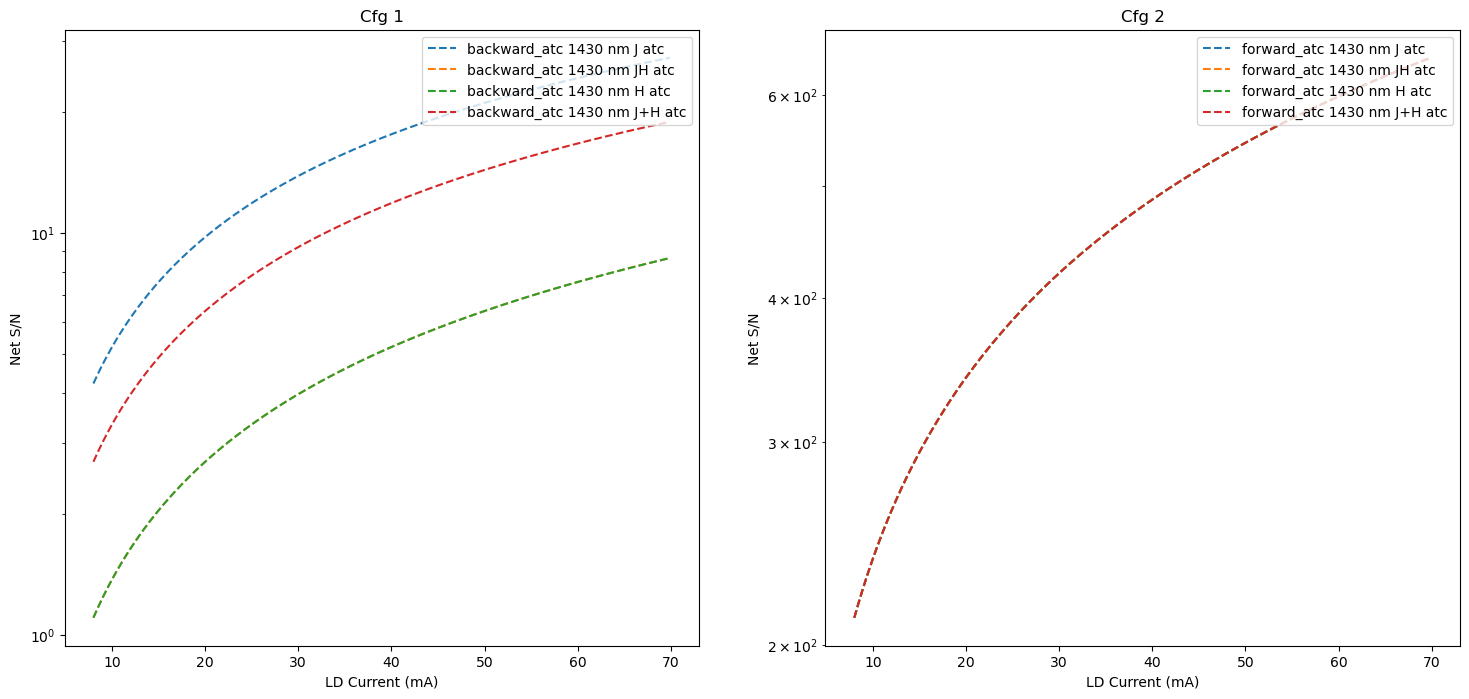

In [14]:
# Cfg1 a-d Retro and 2a-g Forward
texp=readout_rates['1a-d_2a-g']
attens=attenuations['1a-d_2a-g']

diodes = [atc_diode]
fei_routes = ['backward_atc']
coupling_key = {'backward_atc':'unity','forward_atc':'unity'}
detectors = {'backward_atc':atc, 'forward_atc':atc}

plt.figure(figsize=(18,8))
plt.subplot(121)
doplot(fei_routes, coupling_key, detectors, attens, texp, fei_throughputs, exclude_reflected_diode=False)
plt.semilogy()
plt.title('Cfg 1')
fei_routes = ['forward_atc']
plt.subplot(122)
doplot(fei_routes, coupling_key, detectors, attens, texp, fei_throughputs, exclude_reflected_diode=False)
plt.title('Cfg 2')
plt.semilogy()

forward_atc atc unity
ET for atc in forward is 0.1 s
ET for atc in forward is 0.1 s
ET for atc in forward is 0.1 s
ET for atc in forward is 0.1 s
ET for atc in forward is 0.1 s
ET for atc in forward is 0.1 s
ET for atc in forward is 0.1 s
ET for atc in forward is 0.1 s
forward_bfocus bspec normal
Skipping reflected diode for forward_bfocus:H:1430 nm.
ET for bspec in forward is 0.05 s
1040.0 nm diode_pixels 1.0 pix are unresolved in (140, 1038.24497031, 1047.54497031)
1040.0 nm diode_pixels 1.0 pix are unresolved in (141, 1030.85032513, 1040.15032513)
Skipping reflected diode for forward_bfocus:JH:1430 nm.
ET for bspec in forward is 0.05 s
1040.0 nm diode_pixels 1.0 pix are unresolved in (140, 1038.24497031, 1047.54497031)
1040.0 nm diode_pixels 1.0 pix are unresolved in (141, 1030.85032513, 1040.15032513)
Skipping reflected diode for forward_bfocus:J:1430 nm.
ET for bspec in forward is 0.05 s
1040.0 nm diode_pixels 1.0 pix are unresolved in (140, 1038.24497031, 1047.54497031)
1040.0 nm

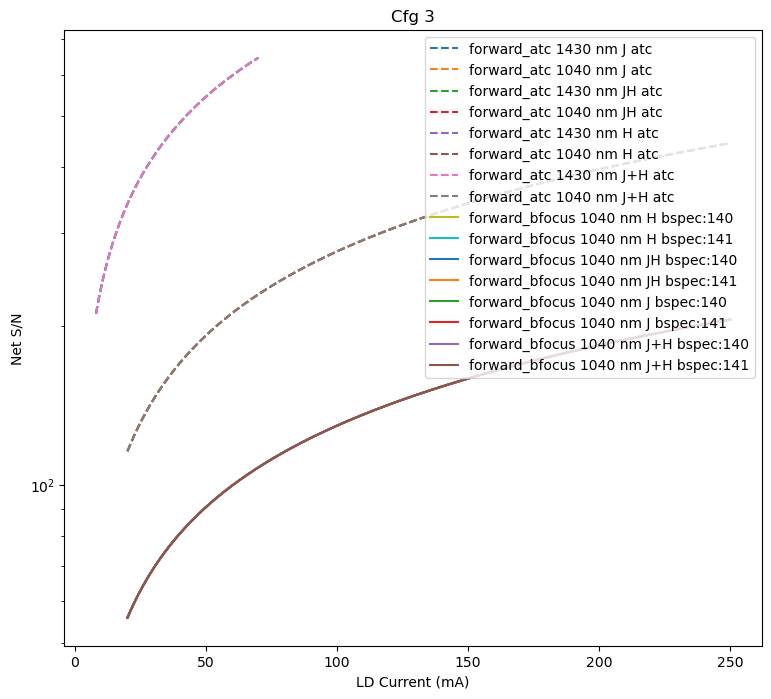

In [15]:
# Cfg3 a-d
diodes = [atc_diode, forward_y_diode]
fei_routes = ['forward_atc', 'forward_bfocus']
coupling_key = {'forward_atc':'unity', 'forward_bfocus':'normal'}
detectors = {'forward_atc':atc, 'forward_bfocus':bspec}

texp=readout_rates['3a-d']
attens=attenuations['3a-d']


plt.figure(figsize=(9,8))
result=doplot(fei_routes, coupling_key, detectors, attens, texp, fei_throughputs, exclude_reflected_diode=True)
plt.semilogy()
plt.title('Cfg 3');
#plt.plot(result[('forward_bfocus', 'JH', 1040)][1][140].snr.mean(1))

forward_atc atc 0.0001
ET for atc in forward is 0.16666666666666666 s
ET for atc in forward is 0.16666666666666666 s
ET for atc in forward is 0.16666666666666666 s
ET for atc in forward is 0.16666666666666666 s
forward_bfocus bspec vortex_dark
ET for bspec in forward is 0.05 s
1270.0 nm diode_pixels 1.0 pix are unresolved in (115, 1263.90692038, 1275.30692038)
ET for bspec in forward is 0.05 s
1270.0 nm diode_pixels 1.0 pix are unresolved in (115, 1263.90692038, 1275.30692038)
Skipping reflected diode for forward_bfocus:J:1270 nm.
Skipping reflected diode for forward_bfocus:J+H:1270 nm.
forward_atc atc 0.0001
ET for atc in forward is 0.16666666666666666 s
ET for atc in forward is 0.16666666666666666 s
ET for atc in forward is 0.16666666666666666 s
ET for atc in forward is 0.16666666666666666 s
forward_bfocus bspec vortex
ET for bspec in forward is 0.05 s
1270.0 nm diode_pixels 1.0 pix are unresolved in (115, 1263.90692038, 1275.30692038)
ET for bspec in forward is 0.05 s
1270.0 nm diod

[]

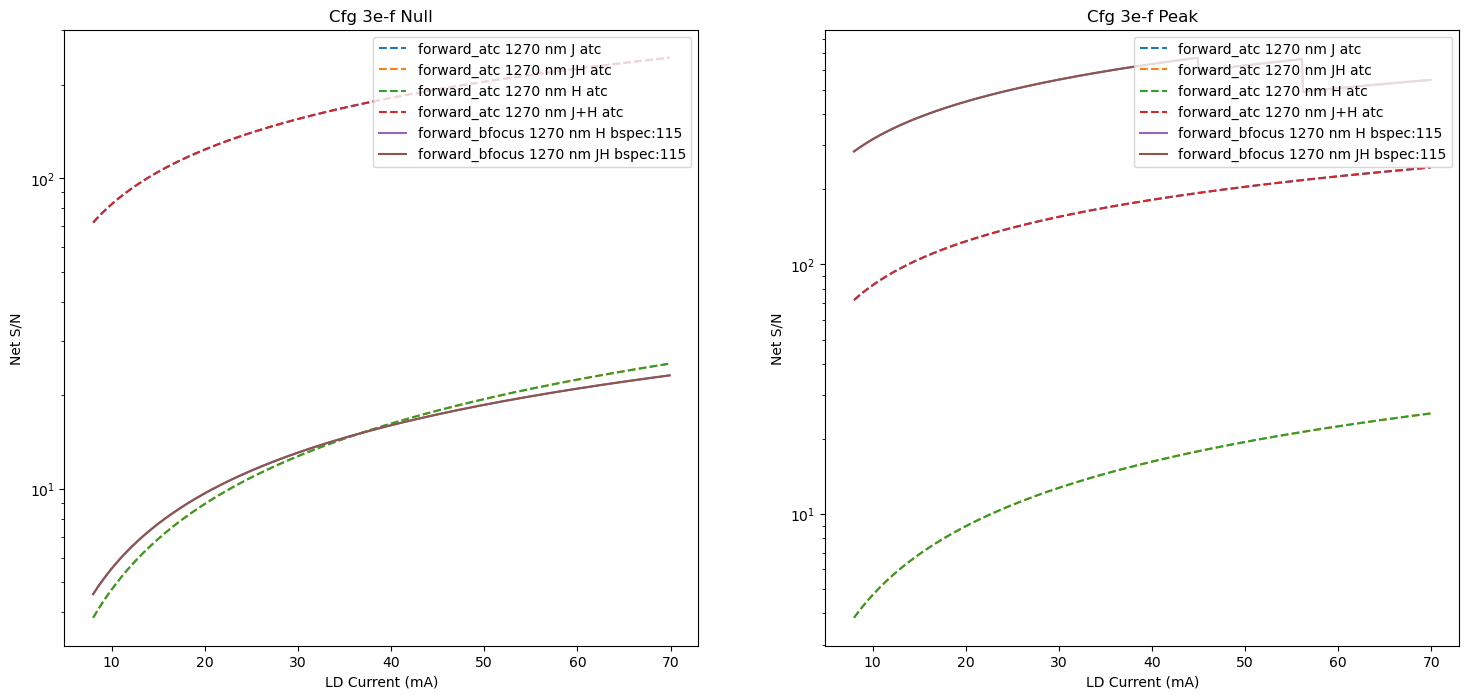

In [6]:
# Cfg3 e-f
diodes = [ forward_j_diode]
fei_routes = ['forward_atc','forward_bfocus']
coupling_key = {'forward_atc':1e-4, 'forward_bfocus':'vortex_dark'}
detectors = {'forward_atc':atc, 'forward_bfocus':bspec}

texp=readout_rates['3e-f']
attens=attenuations['3e-f']


plt.figure(figsize=(18,8))
plt.subplot(121)
doplot(fei_routes, coupling_key, detectors, attens, texp, fei_throughputs, exclude_reflected_diode=True, collapse_func=np.sum)
plt.title('Cfg 3e-f Null')
plt.semilogy()

coupling_key.update({'forward_bfocus':'vortex'})
plt.subplot(122)
result=doplot(fei_routes, coupling_key, detectors, attens, texp, fei_throughputs, exclude_reflected_diode=True, collapse_func=np.sum)
# result[('forward_rfocus', 'JH', 2330)][1][62].saturation_mask.any()
plt.title('Cfg 3e-f Peak')
plt.semilogy()

forward_atc atc 0.0001
ET for atc in forward is 0.16666666666666666 s
ET for atc in forward is 0.16666666666666666 s
ET for atc in forward is 0.16666666666666666 s
ET for atc in forward is 0.16666666666666666 s
forward_bfocus bfemto normal
ET for bfemto in forward is 0.05 s
ET for bfemto in forward is 0.05 s
ET for bfemto in forward is 0.05 s
ET for bfemto in forward is 0.05 s
forward_atc atc 0.0001
ET for atc in forward is 0.16666666666666666 s
ET for atc in forward is 0.16666666666666666 s
ET for atc in forward is 0.16666666666666666 s
ET for atc in forward is 0.16666666666666666 s
ET for atc in forward is 0.16666666666666666 s
ET for atc in forward is 0.16666666666666666 s
ET for atc in forward is 0.16666666666666666 s
ET for atc in forward is 0.16666666666666666 s
forward_rfocus rfemto normal
ET for rfemto in forward is 0.05 s
ET for rfemto in forward is 0.05 s
ET for rfemto in forward is 0.05 s
ET for rfemto in forward is 0.05 s
Skipping reflected diode for forward_rfocus:H:1510 n

[]

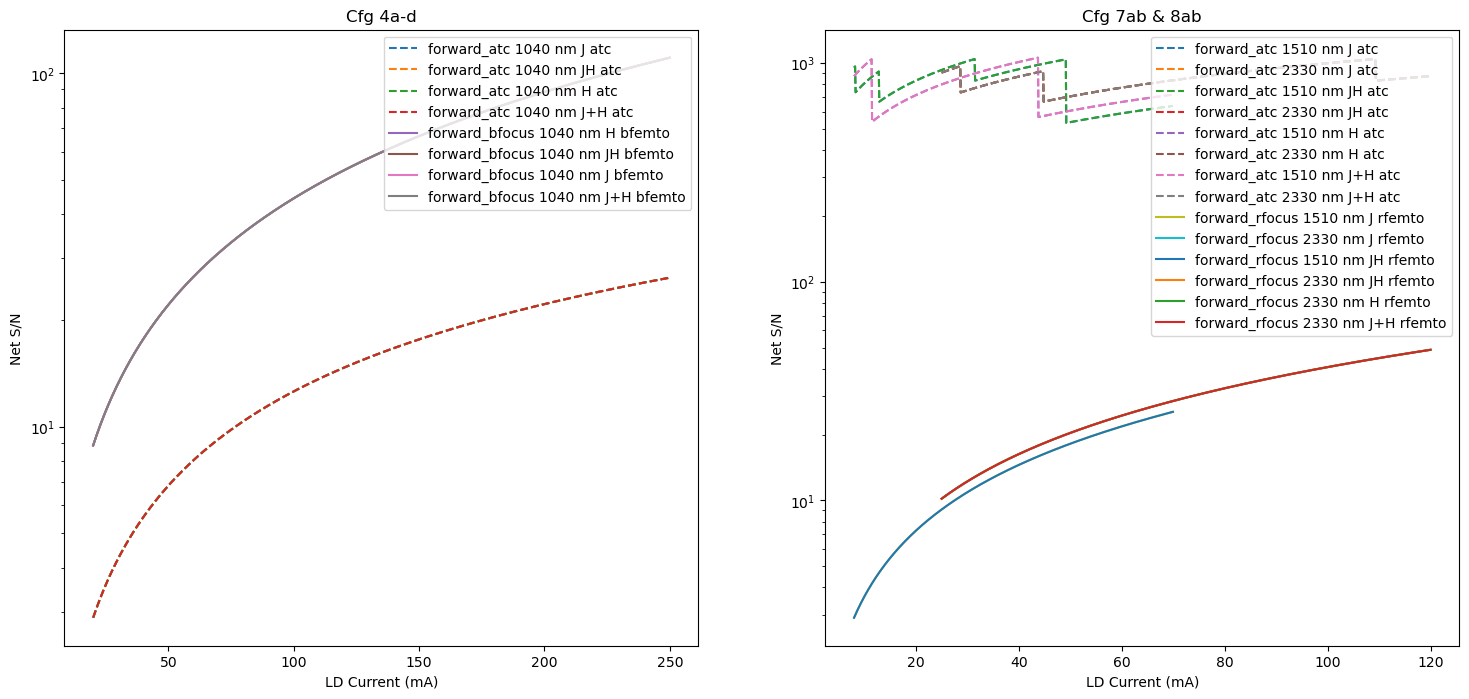

In [12]:
# Cfg 4a-d, 7ab, 8ab
diodes = [forward_y_diode]
fei_routes = ['forward_atc', 'forward_bfocus']
coupling_key = {'forward_atc':1e-4, 'forward_bfocus':'normal', 'forward_rfocus':'normal'}
detectors = {'forward_atc':atc, 'forward_bfocus':bfemto, 'forward_rfocus':rfemto}

texp=readout_rates['4a-d_7ab_8ab']
attens=attenuations['4a-d_7ab_8ab']

plt.figure(figsize=(18,8))
plt.subplot(121)
doplot(fei_routes, coupling_key, detectors, attens, texp, fei_throughputs, exclude_reflected_diode=True)
plt.semilogy()
plt.title('Cfg 4a-d')

# Cfg7&8
diodes = [forward_h_diode, forward_k_diode]
fei_routes = ['forward_atc', 'forward_rfocus']
plt.subplot(122)
doplot(fei_routes, coupling_key, detectors, attens, texp, fei_throughputs, exclude_reflected_diode=True)
plt.title('Cfg 7ab & 8ab')
plt.semilogy()

forward_atc atc 0.01
ET for atc in forward is 0.16666666666666666 s
ET for atc in forward is 0.16666666666666666 s
ET for atc in forward is 0.16666666666666666 s
ET for atc in forward is 0.16666666666666666 s
ET for atc in forward is 0.16666666666666666 s
ET for atc in forward is 0.16666666666666666 s
ET for atc in forward is 0.16666666666666666 s
ET for atc in forward is 0.16666666666666666 s
forward_rfocus rspec normal
Skipping reflected diode for forward_rfocus:J:1430 nm.
ET for rspec in forward is 0.05 s
1510.0 nm diode_pixels 1.0 pix are unresolved in (96, 1499.12291368, 1521.22291368)
Skipping reflected diode for forward_rfocus:JH:1430 nm.
ET for rspec in forward is 0.05 s
1510.0 nm diode_pixels 1.0 pix are unresolved in (96, 1499.12291368, 1521.22291368)
Skipping reflected diode for forward_rfocus:H:1430 nm.
Skipping reflected diode for forward_rfocus:H:1510 nm.
Skipping reflected diode for forward_rfocus:J+H:1430 nm.
Skipping reflected diode for forward_rfocus:J+H:1510 nm.
forw

[]

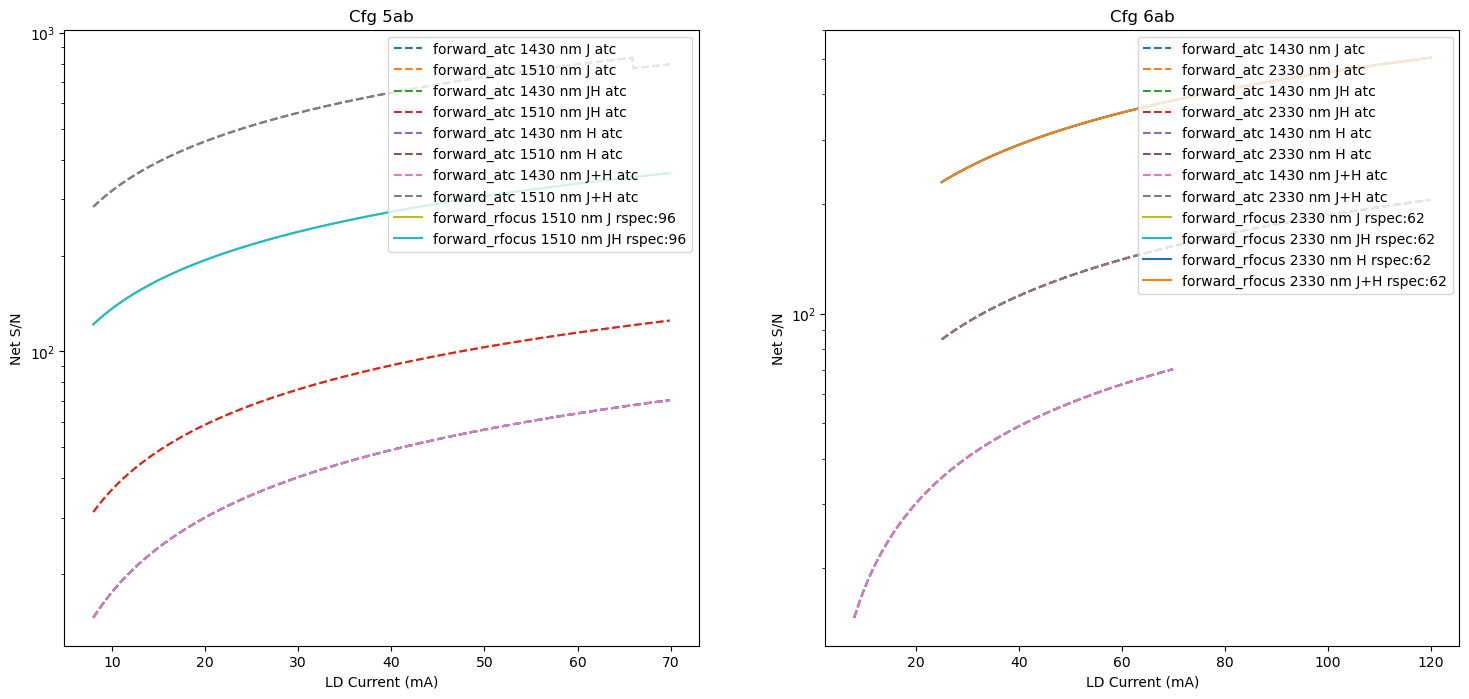

In [8]:
# Cfg5ab Cfg6ab
diodes = [atc_diode, forward_h_diode]
fei_routes = ['forward_atc', 'forward_rfocus']
coupling_key = {'forward_atc':1e-2, 'forward_rfocus':'normal'}
detectors = {'forward_atc':atc, 'forward_rfocus':rspec}

attens = attenuations['5ab_6ab']
texp = readout_rates['5ab_6ab']

plt.figure(figsize=(18,8))
plt.subplot(121)
doplot(fei_routes, coupling_key, detectors, attens, texp, fei_throughputs, exclude_reflected_diode=True)
plt.title('Cfg 5ab')
plt.semilogy()

diodes = [atc_diode, forward_k_diode]
plt.subplot(122)
result=doplot(fei_routes, coupling_key, detectors, attens, texp, fei_throughputs, exclude_reflected_diode=True)
# result[('forward_rfocus', 'JH', 2330)][1][62].saturation_mask.any()
plt.title('Cfg 6ab')
plt.semilogy()

forward_atc atc 1e-07
ET for atc in forward is 0.16666666666666666 s
ET for atc in forward is 0.16666666666666666 s
ET for atc in forward is 0.16666666666666666 s
ET for atc in forward is 0.16666666666666666 s
ET for atc in forward is 0.16666666666666666 s
ET for atc in forward is 0.16666666666666666 s
ET for atc in forward is 0.16666666666666666 s
ET for atc in forward is 0.16666666666666666 s
forward_bfocus bfemto vortex_dark
ET for bfemto in forward is 0.05 s
No FEI transmission for forward_bfocus:H:2330 nm.
ET for bfemto in forward is 0.05 s
No FEI transmission for forward_bfocus:JH:2330 nm.
Skipping reflected diode for forward_bfocus:J:1270 nm.
No FEI transmission for forward_bfocus:J:2330 nm.
Skipping reflected diode for forward_bfocus:J+H:1270 nm.
No FEI transmission for forward_bfocus:J+H:2330 nm.
forward_rfocus rfemto vortex_dark
Skipping reflected diode for forward_rfocus:J:1270 nm.
ET for rfemto in forward is 0.05 s
No FEI transmission for forward_rfocus:JH:1270 nm.
ET for r

[]

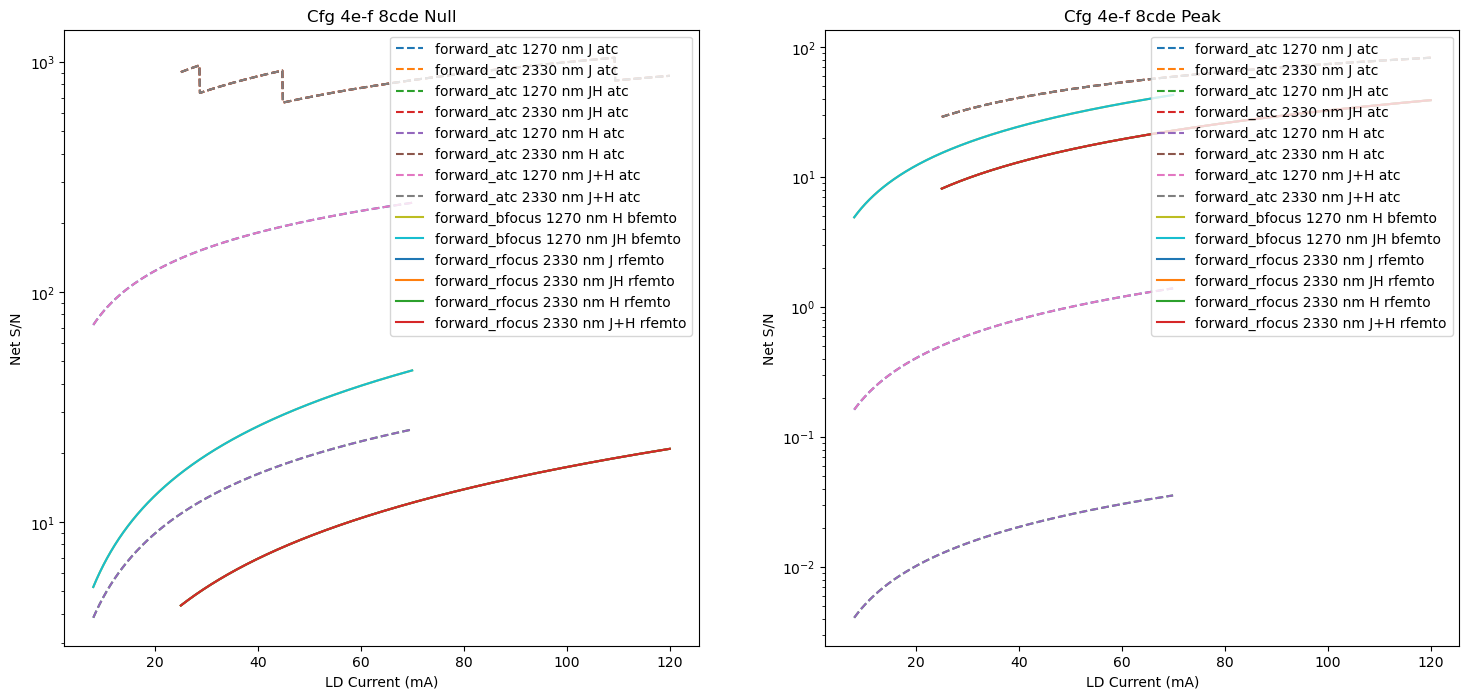

In [9]:
# Cfg 4e-f, 8cde
diodes = [forward_j_diode, forward_k_diode]
fei_routes = ['forward_atc', 'forward_bfocus', 'forward_rfocus']
coupling_key = {'forward_atc':1e-7, 'forward_bfocus':'vortex_dark', 'forward_rfocus':'vortex_dark'}
detectors = {'forward_atc':atc, 'forward_bfocus':bfemto, 'forward_rfocus':rfemto}

texp = readout_rates['4e-f_8c-e']
attens = attenuations['4e-f_8c-e']['vortex_dark']

plt.figure(figsize=(18, 8))
plt.subplot(121)
result1 = doplot(fei_routes, coupling_key, detectors, attens, texp, fei_throughputs, exclude_reflected_diode=True, collapse_func=np.sum)
plt.title('Cfg 4e-f 8cde Null')
plt.semilogy()

coupling_key.update({'forward_bfocus': 'vortex', 'forward_rfocus':'vortex'})
attens = attenuations['4e-f_8c-e']['vortex']

plt.subplot(122)
result2 = doplot(fei_routes, coupling_key, detectors, attens, texp, fei_throughputs, exclude_reflected_diode=True, collapse_func=np.sum)
# result[('forward_rfocus', 'JH', 2330)][1][62].saturation_mask.any()
plt.title('Cfg 4e-f 8cde Peak')
plt.semilogy()

forward_atc atc 0.0001
ET for atc in forward is 0.16666666666666666 s
ET for atc in forward is 0.16666666666666666 s
ET for atc in forward is 0.16666666666666666 s
ET for atc in forward is 0.16666666666666666 s
forward_rfocus rspec vortex_dark
ET for rspec in forward is 0.05 s
2330.0 nm diode_pixels 1.0 pix are unresolved in (62, 2321.27741473, 2355.37741473)
ET for rspec in forward is 0.05 s
2330.0 nm diode_pixels 1.0 pix are unresolved in (62, 2321.27741473, 2355.37741473)
ET for rspec in forward is 0.05 s
2330.0 nm diode_pixels 1.0 pix are unresolved in (62, 2321.27741473, 2355.37741473)
ET for rspec in forward is 0.05 s
2330.0 nm diode_pixels 1.0 pix are unresolved in (62, 2321.27741473, 2355.37741473)
forward_atc atc 0.0001
ET for atc in forward is 0.16666666666666666 s
ET for atc in forward is 0.16666666666666666 s
ET for atc in forward is 0.16666666666666666 s
ET for atc in forward is 0.16666666666666666 s
forward_rfocus rspec vortex
ET for rspec in forward is 0.05 s
2330.0 nm d

[]

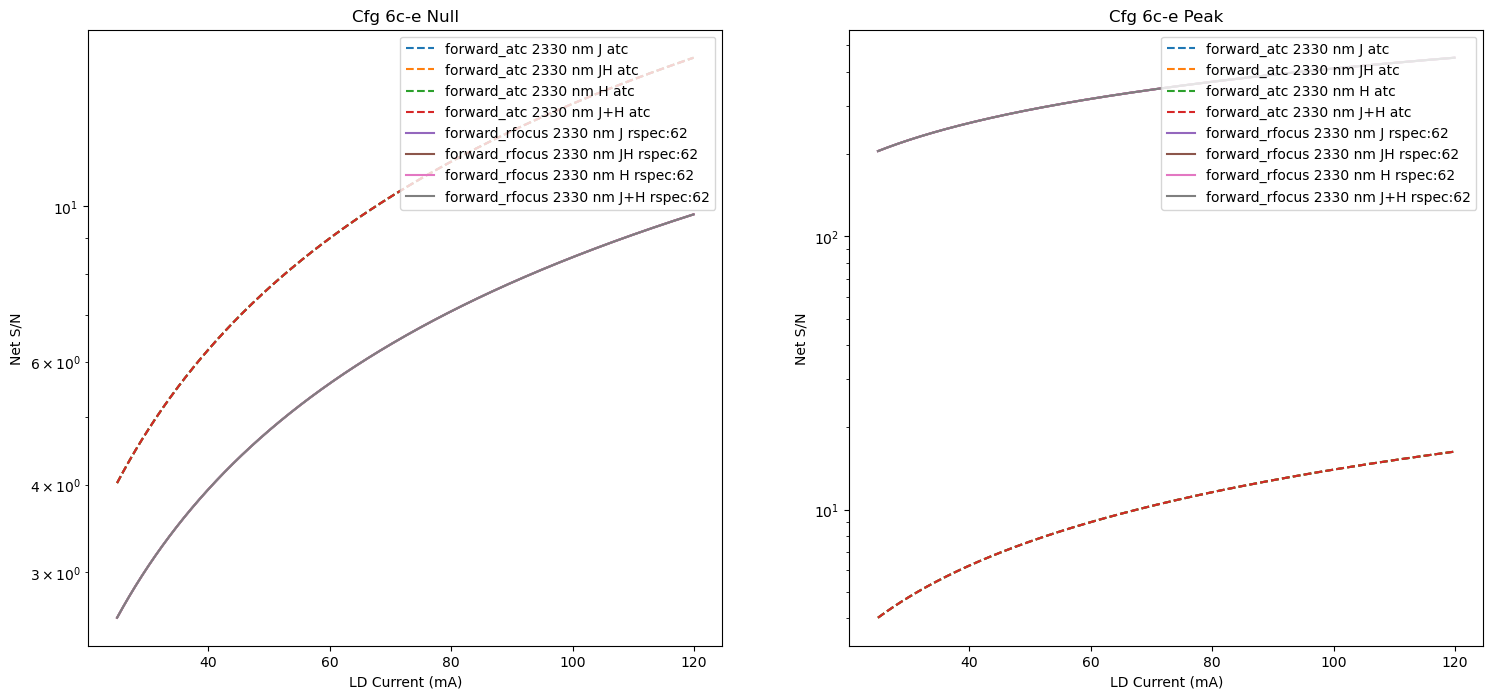

In [10]:
# Cfg6c-e
diodes = [forward_k_diode]
fei_routes = ['forward_atc', 'forward_rfocus']
coupling_key = {'forward_atc': 1e-4, 'forward_rfocus': 'vortex_dark'}

detectors = {'forward_atc': atc, 'forward_rfocus': rspec}

attens = attenuations['6c-e']
texp = readout_rates['6c-e']


plt.figure(figsize=(18, 8))
plt.subplot(121)
doplot(fei_routes, coupling_key, detectors, attens, texp, fei_throughputs, exclude_reflected_diode=True)
plt.title('Cfg 6c-e Null')
plt.semilogy()

coupling_key = {'forward_atc': 1e-4, 'forward_rfocus': 'vortex'}
plt.subplot(122)
result = doplot(fei_routes, coupling_key, detectors, attens, texp, fei_throughputs, exclude_reflected_diode=True)
# result[('forward_rfocus', 'JH', 2330)][1][62].saturation_mask.any()
plt.title('Cfg 6c-e Peak')
plt.semilogy()

### Attenuator exploration

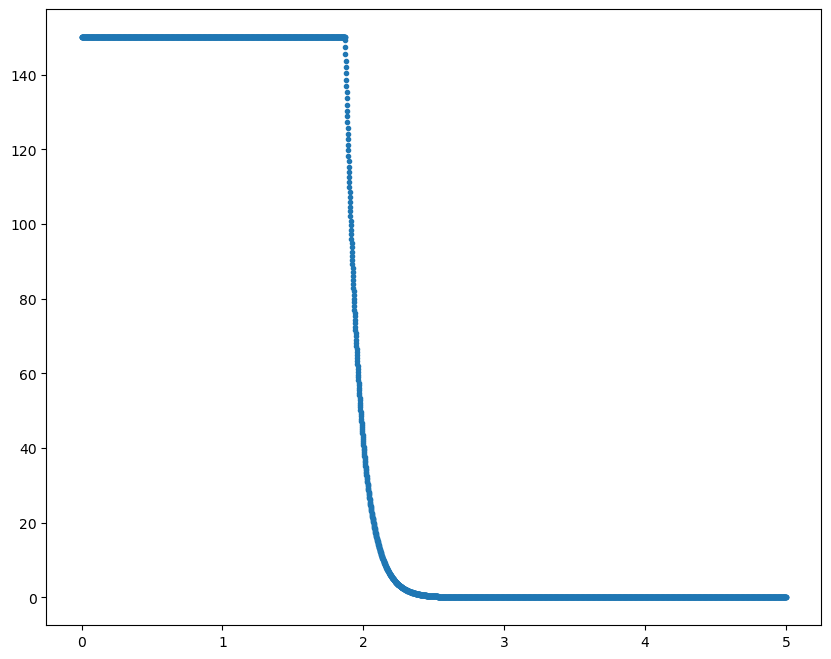

In [10]:
import numpy as np
import matplotlib.pyplot as plt
atten = (0, 70)
bits = 12
fvoa_db = np.poly1d(np.polyfit((1.87, 3.25), (0, 60), 1))
msoa_db = np.poly1d(np.polyfit((0.5, 3.25), (0, 70), 1))
voltage = np.linspace(0, 5, num=2 ** bits)

plt.figure(figsize=(10, 8))
plt.step(voltage, 10 ** (-fvoa_db(voltage).clip(0,70)/10)*150,'.')